# 09 — Confounder Analysis

**Scientific question:** Are blood-based gene expression biomarkers truly predictive
of tissue pathology, or is the signal driven by donor demographics (age, sex, race, etc.)
that correlate with disease?

Three models per tissue × category:
- **Conf-only** — RF with demographics alone (SEX, AGE, RACE, DTHHRDY, TRISCHD)
- **Expr-only** — RF with expression alone (baseline, from notebook 07)
- **Expr+Conf** — RF with expression + demographics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from gtex_biomarkers.config import Config
from gtex_biomarkers.data import (
    load_cache, variance_filter,
    build_confounder_matrix,
)
from gtex_biomarkers.labels import discover_tissue_category_pairs
from gtex_biomarkers.models import make_rf_model
from gtex_biomarkers.utils import run_all_confounder_models_parallel
from gtex_biomarkers.evaluation import plot_paired_auc_bar, plot_delta_bar

Config.ensure_dirs()

X_wb, blood_subjid, _, df_meta_url, df_age = load_cache()

Loaded cache from /Users/rsinha/Library/CloudStorage/OneDrive-SanfordBurnhamPrebysMedicalDiscoveryInstitute/Desktop/gtex_gene_expression/data/cache/processed_data.pkl
  X_wb: 803 samples × 59033 genes


## 9.1 — Build Confounder Matrix

Map donor-level demographics (SEX, AGE, RACE, DTHHRDY, TRISCHD) to each blood sample.
RACE codes 98/99 (unknown) are treated as NaN and median-imputed.

In [2]:
X_conf = build_confounder_matrix(df_age, blood_subjid)
print(f"Confounder matrix: {X_conf.shape[0]} samples × {X_conf.shape[1]} features")
print(f"Features: {list(X_conf.columns)}")
print()
display(X_conf.describe().round(2))
display(X_conf.head(10))

Confounder matrix: 803 samples × 5 features
Features: ['SEX', 'AGE', 'RACE', 'DTHHRDY', 'TRISCHD']



,SEX,AGE,RACE,DTHHRDY,TRISCHD
count,803.00,803.00,803.00,803.00,803.00
mean,1.33,52.81,2.85,1.12,491.91
std,0.47,13.03,0.40,1.40,410.54
min,1.00,20.00,1.00,0.00,0.00
25%,1.00,47.00,3.00,0.00,79.00
50%,1.00,55.00,3.00,0.00,447.00
75%,2.00,63.00,3.00,2.00,824.50
max,2.00,70.00,4.00,4.00,1641.00


,SEX,AGE,RACE,DTHHRDY,TRISCHD
GTEX-1117F-0005-SM-HL9SH,2.0,66.0,2.0,4.0,1200.0
GTEX-111CU-0005-SM-GJ3PH,1.0,57.0,3.0,0.0,43.0
GTEX-111FC-0006-SM-H65Z1,1.0,61.0,3.0,1.0,1028.0
GTEX-111YS-0006-SM-5NQBE,1.0,62.0,3.0,0.0,74.0
GTEX-1122O-0005-SM-5O99J,2.0,64.0,3.0,0.0,35.0
GTEX-1128S-0005-SM-5P9HI,2.0,66.0,3.0,2.0,816.0
GTEX-113IC-0006-SM-5NQ9C,1.0,66.0,2.0,0.0,94.0
GTEX-113JC-0006-SM-5O997,2.0,53.0,3.0,2.0,611.0
GTEX-117XS-0005-SM-5PNU6,1.0,64.0,3.0,2.0,848.0
GTEX-117YW-0005-SM-5NQ8Z,1.0,58.0,3.0,3.0,785.0


## 9.2 — Discover Tissue × Category Pairs

In [3]:
pairs_df = discover_tissue_category_pairs(df_meta_url)
print(f"Total tissue × category pairs (≥ {Config.ALL_TISSUE_THRESHOLD} samples): {len(pairs_df)}")
display(pairs_df)

Total tissue × category pairs (≥ 50 samples): 53


,tissue,category,n_samples
0,Adipose - Subcutaneous,fibrosis,137
1,Adipose - Visceral (Omentum),fibrosis,99
2,Artery - Aorta,atherosis,221
3,Artery - Aorta,atherosclerosis,101
4,Artery - Aorta,sclerotic,64
5,Artery - Aorta,calcification,53
6,Artery - Coronary,calcification,158
7,Artery - Coronary,atherosclerosis,153
8,Artery - Coronary,sclerotic,124
9,Artery - Coronary,atherosis,116


## 9.3 — Run Models (Parallelized by Tissue)

For each tissue × category pair, train two RF models:
- **Model A**: Confounders only (SEX, AGE, RACE, DTHHRDY, TRISCHD)
- **Model B**: Variance-filtered expression (top 100 per fold) + all confounders

In [4]:
# Variance-filtered expression (top 20K genes) — same as notebook 07
X_wb_var, _ = variance_filter(X_wb)
print(f"Variance-filtered expression: {X_wb_var.shape[0]} samples × {X_wb_var.shape[1]} genes")

conf_results, conf_summary, comb_results, comb_summary = \
    run_all_confounder_models_parallel(
        pairs_df, df_meta_url, blood_subjid,
        X_wb_var, X_conf, make_rf_model
    )

print(f"Completed {len(conf_results)} confounder-only models")
print(f"Completed {len(comb_results)} expression+confounder models")

Variance-filtered expression: 803 samples × 20000 genes


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done   6 out of  19 | elapsed:  6.7min remaining: 14.5min
[Parallel(n_jobs=-1)]: Done   8 out of  19 | elapsed:  6.8min remaining:  9.4min
[Parallel(n_jobs=-1)]: Done  10 out of  19 | elapsed:  8.3min remaining:  7.5min
[Parallel(n_jobs=-1)]: Done  12 out of  19 | elapsed:  8.8min remaining:  5.1min
[Parallel(n_jobs=-1)]: Done  14 out of  19 | elapsed:  8.9min remaining:  3.2min
[Parallel(n_jobs=-1)]: Done  16 out of  19 | elapsed: 10.0min remaining:  1.9min


Completed 53 confounder-only models
Completed 53 expression+confounder models


[Parallel(n_jobs=-1)]: Done  19 out of  19 | elapsed: 13.8min finished


## 9.4 — Three-Way Comparison

Merge confounder-only (Model A), expression-only (notebook 07 baseline), and expression+confounder (Model C).

**Delta = AUC(Expr+Conf) − AUC(Conf-only)** — how much does expression add beyond demographics?

In [5]:
# Extract confounder feature importances from conf-only models
conf_imp_rows = []
for tag, res in conf_results.items():
    tissue, category = res["tissue"], res["category"]
    from gtex_biomarkers.labels import assign_donor_labels
    y_full, _, n_pos, n_neg = assign_donor_labels(df_meta_url, tissue, category, blood_subjid)
    keep = y_full.notna()
    X_c = X_conf.loc[keep]
    y_c = y_full.loc[keep].astype(int)
    
    rf = make_rf_model()
    rf.fit(X_c, y_c)
    imp = dict(zip(X_c.columns, rf.feature_importances_))
    
    row = {"tissue": tissue, "category": category, "tag": tag,
           "mean_auc": res["mean_auc"]}
    row.update(imp)
    row["label"] = tag
    row["dominant_confounder"] = max(imp, key=imp.get)
    row["dominant_importance"] = max(imp.values())
    conf_imp_rows.append(row)

conf_imp_df = pd.DataFrame(conf_imp_rows)
conf_imp_df.to_csv(Config.TABLES_DIR / "confounder_feature_importances.csv", index=False)
print(f"Saved confounder feature importances → {len(conf_imp_df)} rows")
display(conf_imp_df.head())

Saved confounder feature importances → 53 rows


,tissue,category,tag,mean_auc,SEX,AGE,RACE,DTHHRDY,TRISCHD,label,dominant_confounder,dominant_importance
0,Adipose - Subcutaneous,fibrosis,Adipose - Subcutaneous | fibrosis,0.506039,0.058236,0.350863,0.040585,0.102687,0.447630,Adipose - Subcutaneous | fibrosis,TRISCHD,0.447630
1,Adipose - Visceral (Omentum),fibrosis,Adipose - Visceral (Omentum) | fibrosis,0.521892,0.047754,0.346947,0.042457,0.083253,0.479589,Adipose - Visceral (Omentum) | fibrosis,TRISCHD,0.479589
2,Artery - Aorta,atherosis,Artery - Aorta | atherosis,0.479772,0.034325,0.339518,0.038632,0.073569,0.513956,Artery - Aorta | atherosis,TRISCHD,0.513956
3,Artery - Aorta,atherosclerosis,Artery - Aorta | atherosclerosis,0.534380,0.042112,0.349540,0.031479,0.082020,0.494849,Artery - Aorta | atherosclerosis,TRISCHD,0.494849
4,Artery - Aorta,sclerotic,Artery - Aorta | sclerotic,0.492839,0.040144,0.330525,0.037216,0.085550,0.506567,Artery - Aorta | sclerotic,TRISCHD,0.506567


In [6]:
# Save model summaries
conf_summary.to_csv(Config.TABLES_DIR / "cv_results_confounder_only.csv", index=False)
comb_summary.to_csv(Config.TABLES_DIR / "cv_results_expr_plus_confounder.csv", index=False)

# Load expression-only RF results (baseline from notebook 07)
expr_only_path = Config.TABLES_DIR / "cv_results_all_tissue_rf.csv"
if not expr_only_path.exists():
    raise FileNotFoundError("Run notebook 07 first to generate expression-only RF results.")
expr_summary = pd.read_csv(expr_only_path)

# Three-way merge
three_way = (
    conf_summary[["tissue", "category", "mean_auc"]]
    .rename(columns={"mean_auc": "auc_conf"})
    .merge(
        expr_summary[["tissue", "category", "mean_auc"]]
        .rename(columns={"mean_auc": "auc_expr"}),
        on=["tissue", "category"], how="inner",
    )
    .merge(
        comb_summary[["tissue", "category", "mean_auc"]]
        .rename(columns={"mean_auc": "auc_comb"}),
        on=["tissue", "category"], how="inner",
    )
)

# Delta: how much does expression add beyond confounders alone?
three_way["delta"] = three_way["auc_comb"] - three_way["auc_conf"]
three_way = three_way.sort_values("auc_expr", ascending=False)
three_way.to_csv(Config.TABLES_DIR / "cv_three_way_comparison.csv", index=False)

print(f"Total models: {len(three_way)}")
print(f"Mean delta (Expr+Conf − Conf-only): {three_way['delta'].mean():.4f}")
print(f"Median delta: {three_way['delta'].median():.4f}")
display(three_way)

Total models: 53
Mean delta (Expr+Conf − Conf-only): 0.0452
Median delta: 0.0351


,tissue,category,auc_conf,auc_expr,auc_comb,delta
0,Breast - Mammary Tissue,gynecomastoid,0.868507,0.881665,0.875403,0.006897
1,Breast - Mammary Tissue,atrophy,0.772285,0.841520,0.844138,0.071853
3,Spleen,congestion,0.720674,0.826177,0.816906,0.096232
21,Liver,cirrhosis,0.566866,0.804298,0.794705,0.227839
2,Breast - Mammary Tissue,hyperplasia,0.754917,0.752899,0.751471,-0.003446
6,Lung,pneumonia,0.640349,0.736086,0.741729,0.101380
4,Pancreas,saponification,0.717051,0.730258,0.731118,0.014067
5,Testis,spermatogenesis,0.650235,0.711798,0.719460,0.069225
9,Muscle - Skeletal,atrophy,0.618750,0.693750,0.691667,0.072917
12,Liver,congestion,0.593976,0.683426,0.683816,0.089840


## 9.5 — Comparison: Expr+Conf vs Conf-only

Side-by-side bar chart showing Expr+Conf AUC vs Conf-only AUC.
The gap shows how much expression adds beyond demographics.

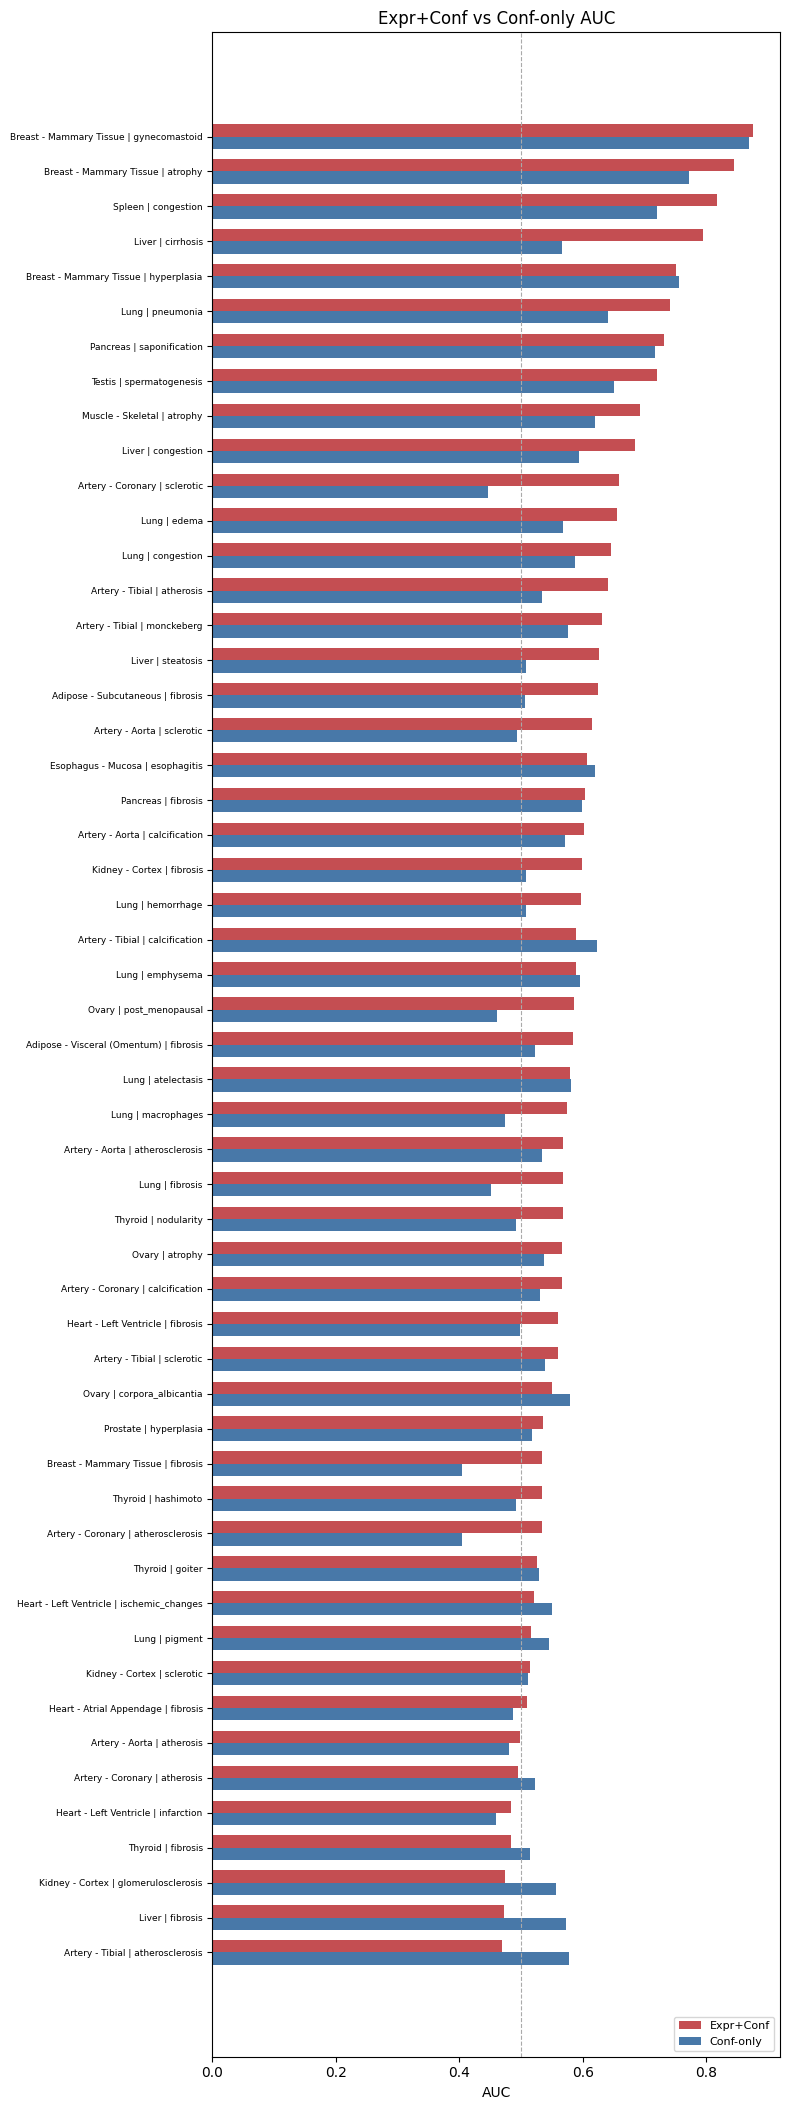

In [7]:
_ = plot_paired_auc_bar(
    three_way, auc_col_a='auc_comb', auc_col_b='auc_conf',
    label_a='Expr+Conf', label_b='Conf-only',
    title='Expr+Conf vs Conf-only AUC',
    save_path=Config.FIGURES_DIR / 'expr_conf_vs_conf_bar.pdf'
)

## 9.6 — ΔAUC Bar Chart

Horizontal bar chart of **ΔAUC = AUC(Expr+Conf) − AUC(Conf-only)** for all 53 tissue × pathology pairs.
Positive Δ means expression adds predictive value beyond demographics alone.

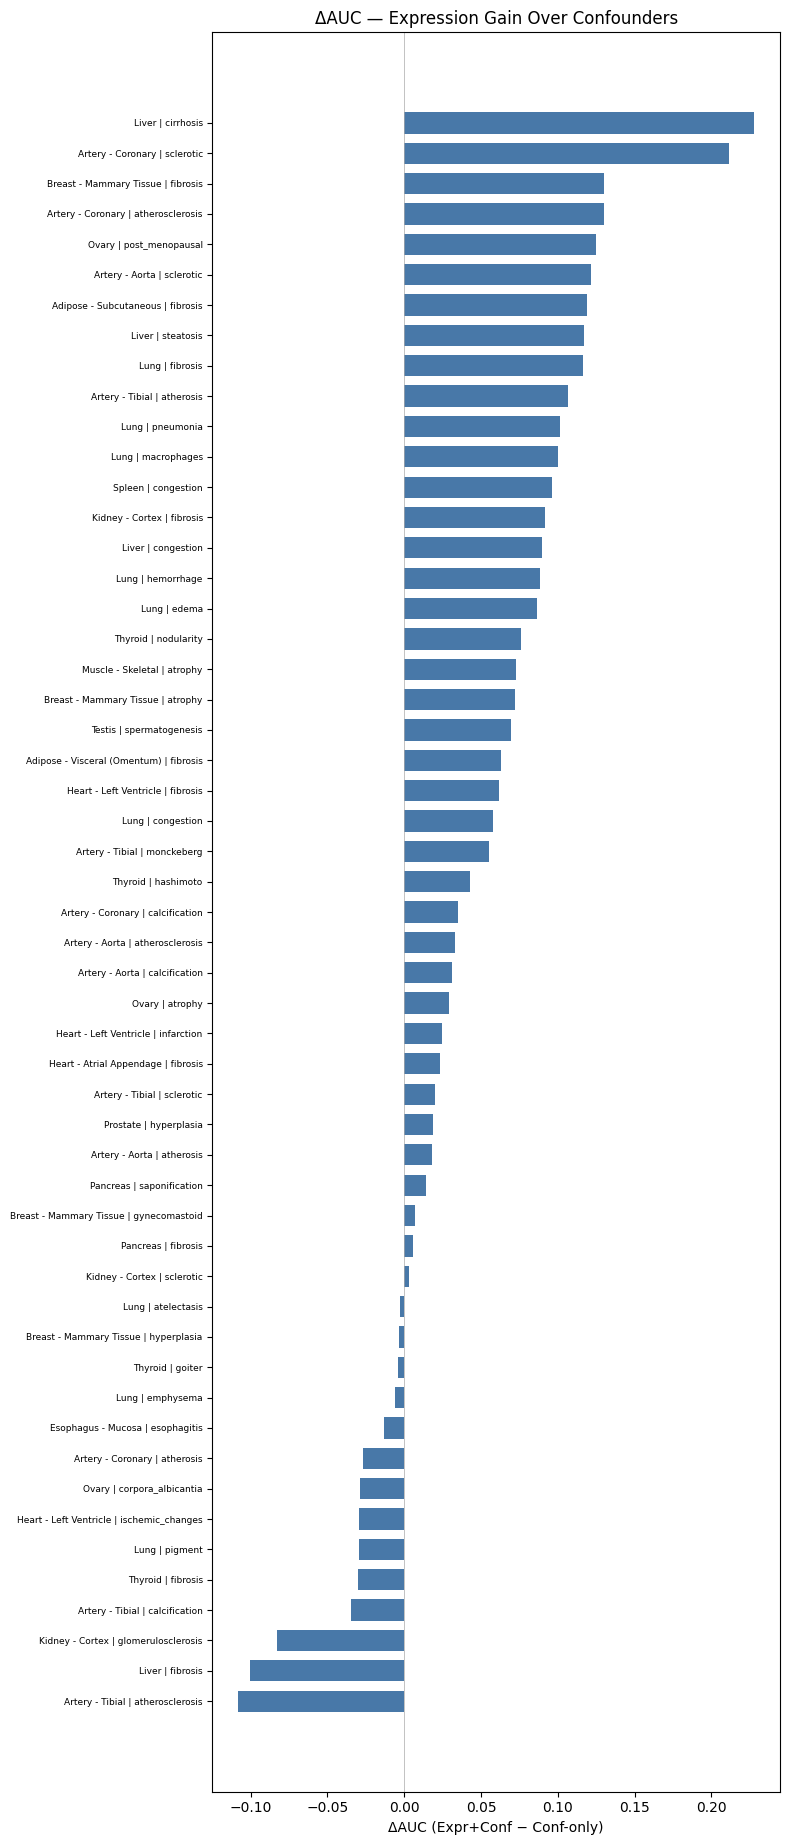

In [8]:
_ = plot_delta_bar(
    three_way, delta_col='delta',
    title='ΔAUC — Expression Gain Over Confounders',
    xlabel='ΔAUC (Expr+Conf − Conf-only)',
    save_path=Config.FIGURES_DIR / 'delta_auc_bar.pdf'
)

## 9.7 — Export Pathology Profiles

Save the master profile table with confounder importances for downstream use.

In [9]:
# Merge confounder importances
profile = three_way[["tissue", "category", "auc_conf", "auc_expr", "auc_comb", "delta"]].merge(
    conf_imp_df[["tissue", "category", "SEX", "AGE", "RACE", "DTHHRDY", "TRISCHD"]],
    on=["tissue", "category"]
)
profile["label"] = profile["tissue"] + " | " + profile["category"]
profile = profile.sort_values("delta", ascending=False).reset_index(drop=True)
profile.to_csv(Config.TABLES_DIR / "pathology_profiles.csv", index=False)
print(f"Saved {len(profile)} rows \u2192 output/tables/pathology_profiles.csv")
display(profile)

Saved 53 rows → output/tables/pathology_profiles.csv


,tissue,category,auc_conf,auc_expr,auc_comb,delta,SEX,AGE,RACE,DTHHRDY,TRISCHD,label
0,Liver,cirrhosis,0.566866,0.804298,0.794705,0.227839,0.040347,0.330397,0.033153,0.152011,0.444093,Liver | cirrhosis
1,Artery - Coronary,sclerotic,0.446685,0.641538,0.658171,0.211486,0.038781,0.325404,0.030752,0.064588,0.540476,Artery - Coronary | sclerotic
2,Breast - Mammary Tissue,fibrosis,0.403861,0.534200,0.534164,0.130304,0.039804,0.366886,0.044498,0.069608,0.479204,Breast - Mammary Tissue | fibrosis
3,Artery - Coronary,atherosclerosis,0.403631,0.525755,0.533720,0.130089,0.036001,0.345383,0.027528,0.069909,0.521179,Artery - Coronary | atherosclerosis
4,Ovary,post_menopausal,0.460490,0.585107,0.585544,0.125053,0.000000,0.376782,0.041028,0.090767,0.491423,Ovary | post_menopausal
5,Artery - Aorta,sclerotic,0.492839,0.605494,0.614266,0.121427,0.040144,0.330525,0.037216,0.085550,0.506567,Artery - Aorta | sclerotic
6,Adipose - Subcutaneous,fibrosis,0.506039,0.634662,0.625030,0.118992,0.058236,0.350863,0.040585,0.102687,0.447630,Adipose - Subcutaneous | fibrosis
7,Liver,steatosis,0.508159,0.624193,0.625269,0.117110,0.042777,0.328456,0.033413,0.081138,0.514217,Liver | steatosis
8,Lung,fibrosis,0.451357,0.584782,0.567472,0.116115,0.038535,0.344435,0.034286,0.067210,0.515534,Lung | fibrosis
9,Artery - Tibial,atherosis,0.534107,0.636132,0.640728,0.106620,0.039969,0.355475,0.050357,0.088121,0.466078,Artery - Tibial | atherosis
